In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from cs336_basics.model import TransformerLM, get_validation_loss

In [2]:
o = torch.load("./train1-smol.step5000.pt", map_location=torch.device('cpu'))
training_loss = o['training_loss']
training_loss = training_loss[training_loss != 0.0]

In [3]:
o.keys()

dict_keys(['model', 'optimizer', 'iteration', 'training_loss'])

In [4]:
from cs336_basics.model import lr_schedule_cosine_annealing

steps = 5000
warmup_steps = 200
lrs = torch.zeros([steps])
for i in range(steps):
    lrs[i] = lr_schedule_cosine_annealing(
            i, lr_max=1e-2, lr_min=5e-4, warmup_period=warmup_steps, annealing_period=steps
        )
lrs

tensor([0.0000e+00, 5.0000e-05, 1.0000e-04,  ..., 5.0001e-04, 5.0000e-04,
        5.0000e-04])

In [6]:
cp_nums = [0, 1000, 2000, 3000, 4000, 5000]
cp_files = [f'train1-smol.step{i}.pt' for i in cp_nums]
with torch.device('mps:0'):
    cp_models = [TransformerLM.from_state_dict(torch.load(f, map_location='mps:0')['model']) for f in cp_files]
validation_dataset = np.load('./tinystories-valid.npy', mmap_mode='r')
# print(validation_dataset.shape, validation_dataset[:100])

cp_validation_loss = [get_validation_loss(model, validation_dataset, batch_size=32, context_length=model.context_length, device='mps:0') for model in cp_models]

(5506693,) [ 117  861  493  500  266  322  607  370  263  910  464   44  338 1963
 2592  349 1601  285 3145  535  392  887  328  263  391  478   46  339
  283  379  795  267  263 3145 1084  550  266 2552  336   46  316 4352
 4215  336  267  393 1101  475  887   46  285 3145  364  506  342  689
  358   46   10  256   10  431  439  259  399   44  313  259 1048  267
 1160  955   44  402  283  259  346 3591   46  438  391  497  403  416
  529  266  325  808  263 3591   46  528  327   44  416 1044  342  668
  476   46]


In [16]:
list(zip(cp_nums, cp_validation_loss))

[(0, 9.212094764286512),
 (1000, 4.3709683775062205),
 (2000, 3.1576847800766057),
 (3000, 2.8440367138559575),
 (4000, 2.5776720053869013),
 (5000, 2.4413981776958913)]

In [46]:
torch.save({
    'checkpoint_stepcount': cp_nums, 
    'checkpoint_validation_loss': cp_validation_loss,
    'lr': lrs.to(dtype=torch.float16),
    'training_loss': training_loss,
    'model_hyper': o['model']['hyper']
}, 'train1-smol.metrics.pt')

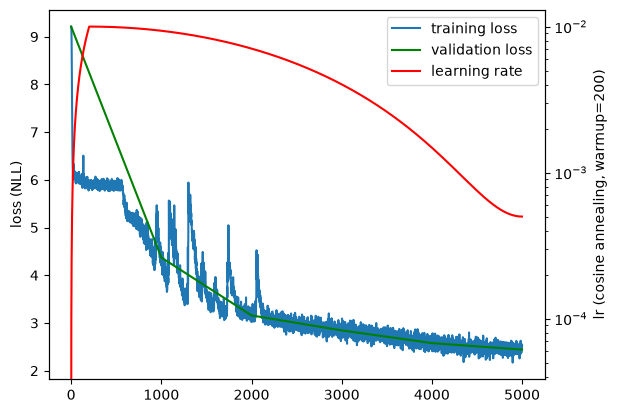

In [41]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html
fig, ax1 = plt.subplots()
ax1.set_ylabel('loss (NLL)')
line_trainloss, = ax1.plot(training_loss, label='training loss')
# validation loss
line_validloss, = ax1.plot(cp_nums, cp_validation_loss, label='validation loss', color='green')
# ax1.legend()

ax2 = ax1.twinx()
ax2.set_yscale('log')
ax2.set_ylabel('lr (cosine annealing, warmup=200)')
line_lr, = ax2.plot(lrs, label='learning rate', color='red')
# ax2.legend()

lines = [line_trainloss, line_validloss, line_lr]
plt.legend(lines, [l.get_label() for l in lines])
plt.show()